# Проект: классификация клиентов банка

# <center> Бизнес-задача: определить характеристики, по которым можно выявить клиентов, более склонных к открытию депозита в банке, и за счёт этого повысить результативность маркетинговой кампании.

# <center> Техническая задача для вас как для специалиста в Data Science: построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать, воспользуется он предложением об открытии депозита или нет.

In [ ]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model,tree,ensemble,metrics,preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

Данные о клиентах банка:  

age (возраст)  
job (сфера занятости)  
marital (семейное положение)  
education (уровень образования)  
default (имеется ли просроченный кредит)  
housing (имеется ли кредит на жильё)  
loan (имеется ли кредит на личные нужды)  
balance (баланс)  

Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:  

contact (тип контакта с клиентом)  
month (месяц, в котором был последний контакт)  
day (день, в который был последний контакт)  
duration (продолжительность контакта в секундах)  

Прочие признаки:  

campaign (количество контактов с этим клиентом в течение текущей кампании)  
pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании)  
previous (количество контактов до текущей кампании)  
poutcome (результат прошлой маркетинговой кампании)  
Целевая переменная: deposit  

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('D:/IDE/data/bank_fin.csv', sep = ';')

* исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?

In [ ]:
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

* есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?

In [ ]:
df['education'].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

### Задание 3

* преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)

In [ ]:
df['balance'] = df['balance'].str.replace(',', '.', regex=False)
df['balance'] = df['balance'].str.replace('$', '', regex=False)
df['balance'] = df['balance'].str.replace(' ', '', regex=False)
df['balance'] = df['balance'].str.strip()
df['balance'] = df['balance'].astype(float)

### Задание 4

* обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку

In [ ]:
df['balance'] = df['balance'].fillna(df['balance'].median())
df['balance'].median()

550.0

### Задание 5

* обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения

In [ ]:
df['job'] = df['job'].apply(lambda x: df['job'].mode()[0] if x == 'unknown' else x)
df['education'] = df['education'].apply(lambda x: df['education'].mode()[0] if x == 'unknown' else x)
df[(df['education'] == df['education'].mode()[0]) & (df['job'] == df['job'].mode()[0])]['balance'].mean()

1598.8829787234042

### Задание 6

* удалите все выбросы для признака balance

In [ ]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return cleaned
    
cleaned = outliers_iqr(df, 'balance')
df = cleaned


## Часть 2:  Разведывательный анализ

### Задание 1

* изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат

deposit
no     5424
yes    4681
Name: count, dtype: int64

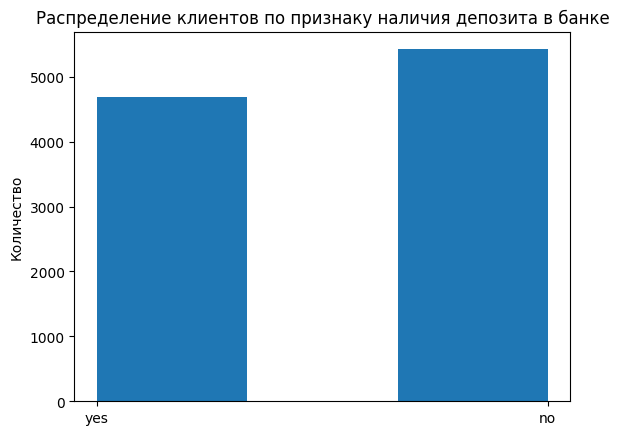

In [ ]:
display(df['deposit'].value_counts())
plt.hist(df['deposit'],bins=3)
plt.ylabel("Количество")
plt.title('Распределение клиентов по признаку наличия депозита в банке')
plt.show()

* Распределение целевого признака нормальное

In [10]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns


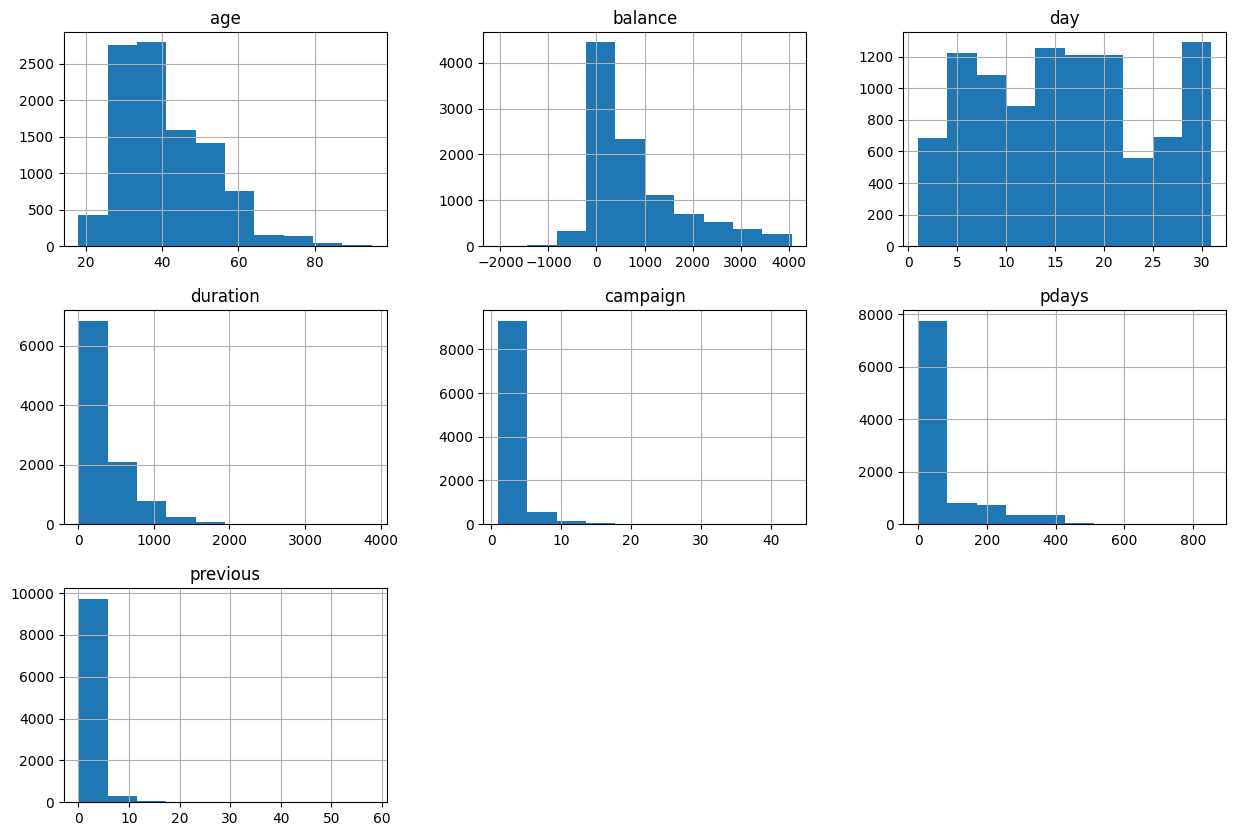

In [11]:
df[num_cols].hist(figsize=(15, 10))
plt.show()

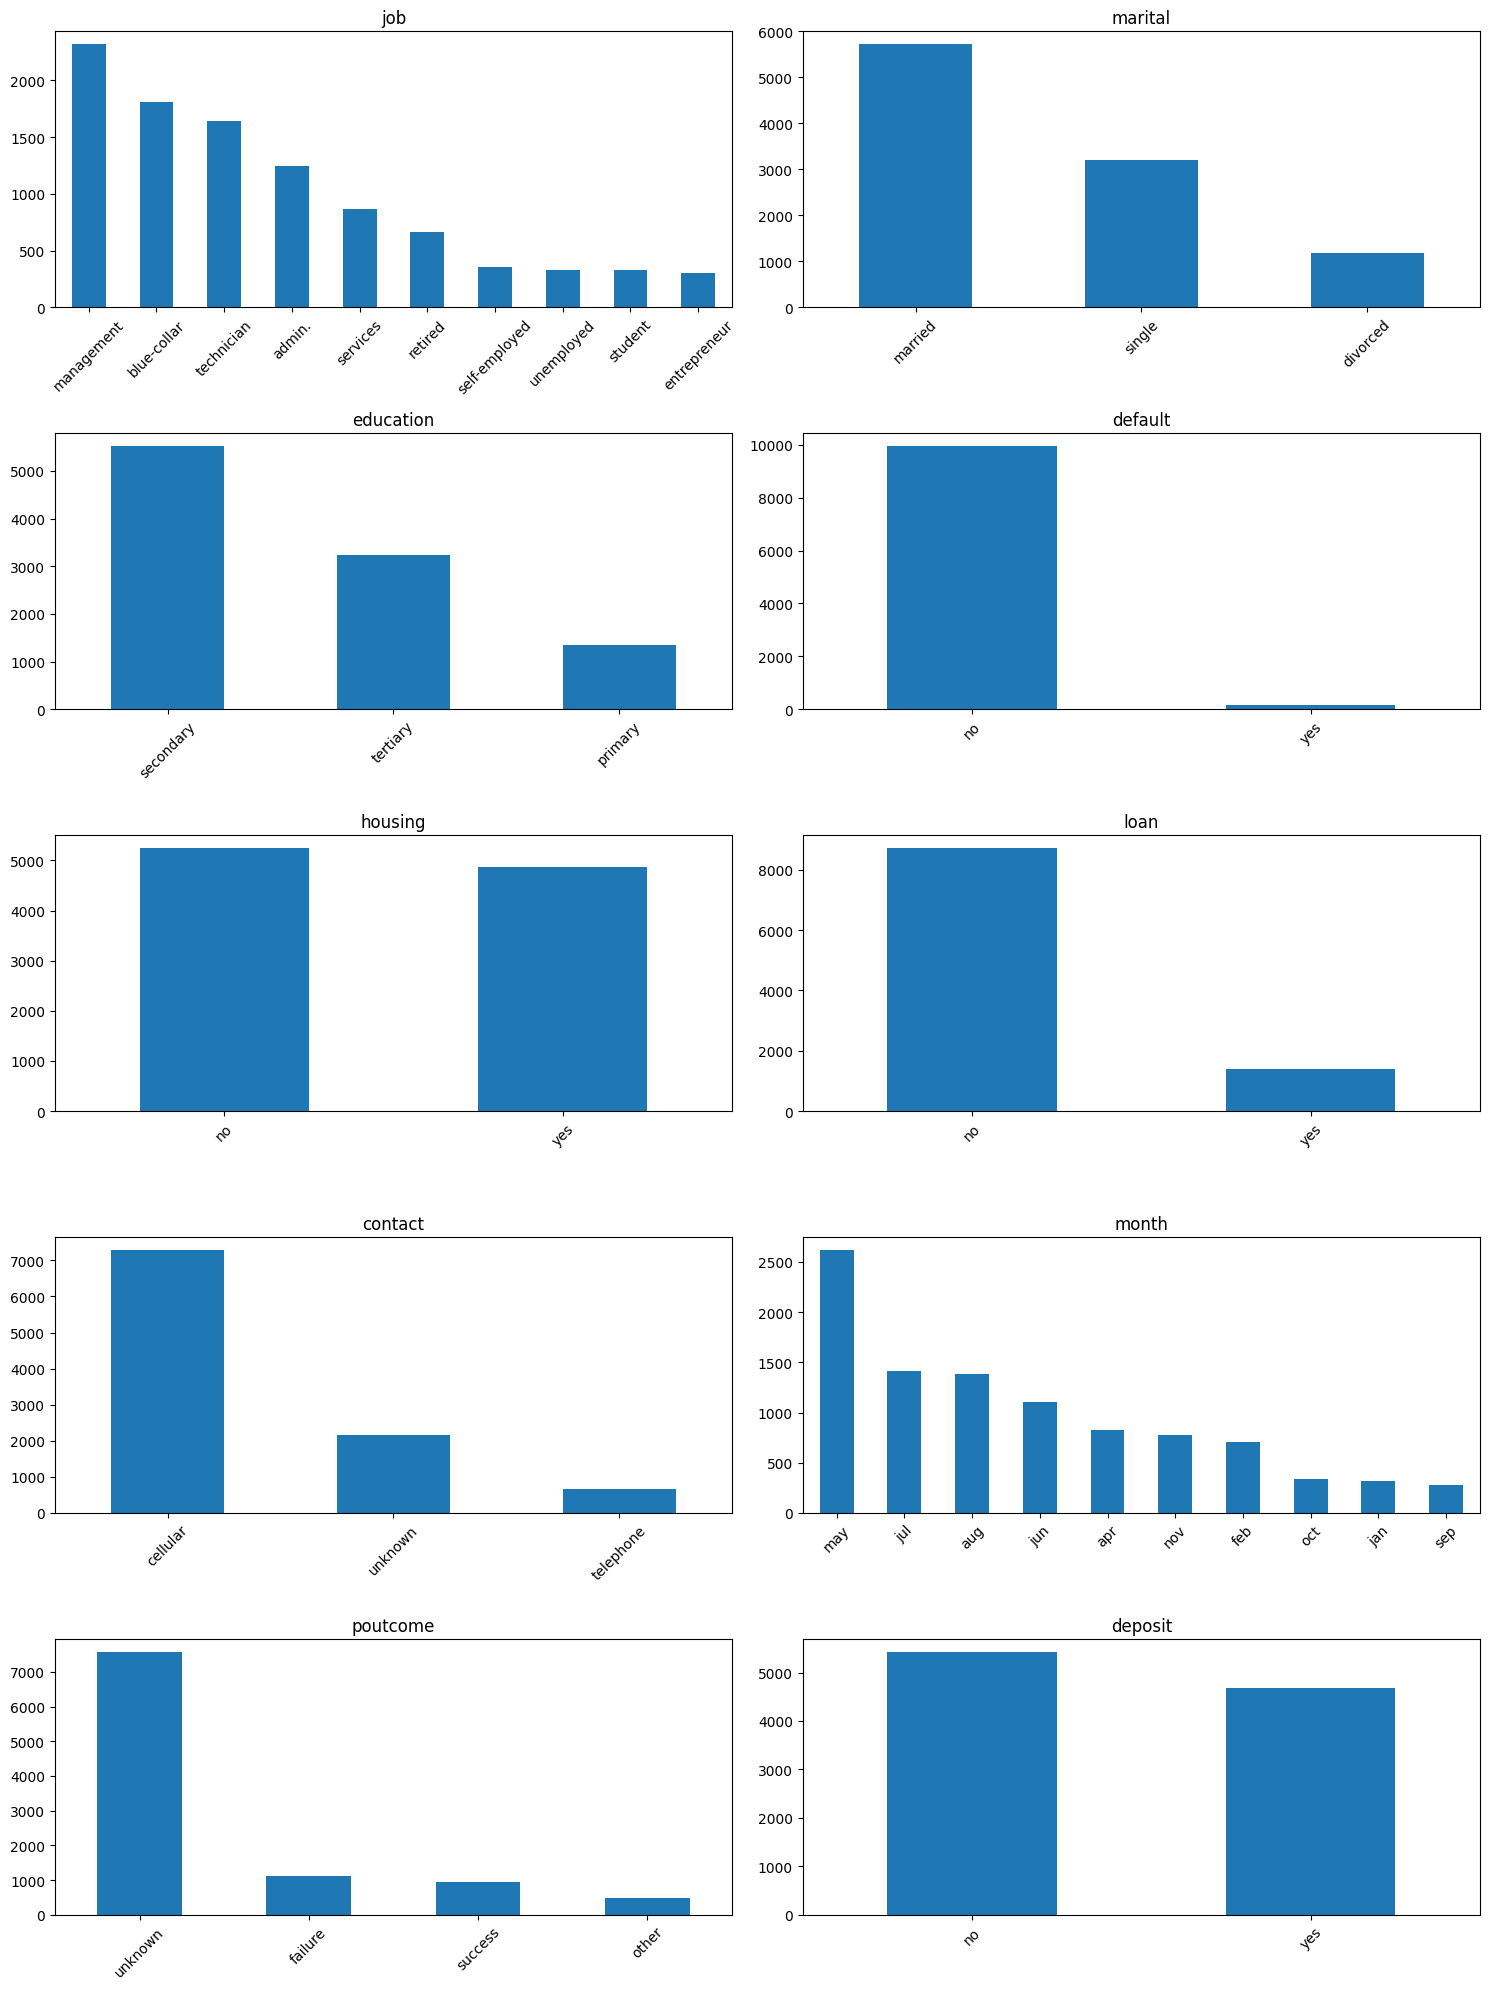

In [12]:
# Настраиваем размеры графика
n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Строим графики
for i, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

# Скрываем пустые графики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Кроме целевого признака нормальным распределением обладает также признак 'housing'

### Задания 2 и 3

* рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат

In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

* рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат

In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


### Задание 6

* Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.

deposit,no,yes
poutcome,,
failure,562,547
other,216,265
success,84,861
unknown,4562,3008


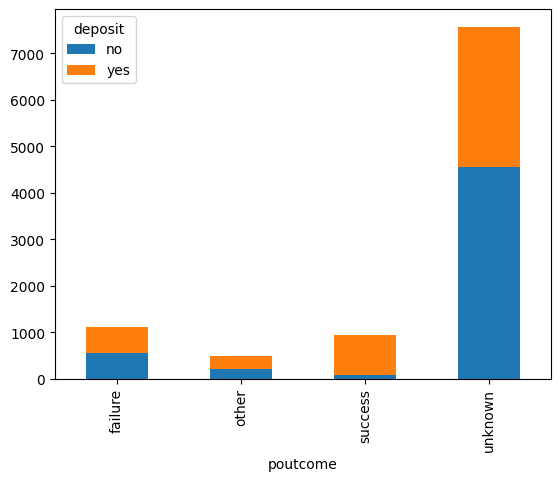

In [ ]:
types = df.groupby(by='poutcome')['deposit'].value_counts(normalize=False).unstack()
types.plot(kind='bar', stacked=True)
types

### Задание 7

* узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит

In [ ]:
result = {}

for x in df['month'].unique():
    result[x] = round(df[(df['month'] == x) & (df['poutcome'] == 'failure')].shape[0] / df[(df['month'] == x) & (df['poutcome'] != 'unknown')].shape[0] * 100, 2)
    
max_key = max(result, key=result.get)

print(f"Месяц, в котором худший процент удачных взаимодействий с клиентом: {max_key}, процент: {result[max_key]}")

Месяц, в котором худший процент удачных взаимодействий с клиентом: may, процент: 59.29


### Задание 8

*  создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения

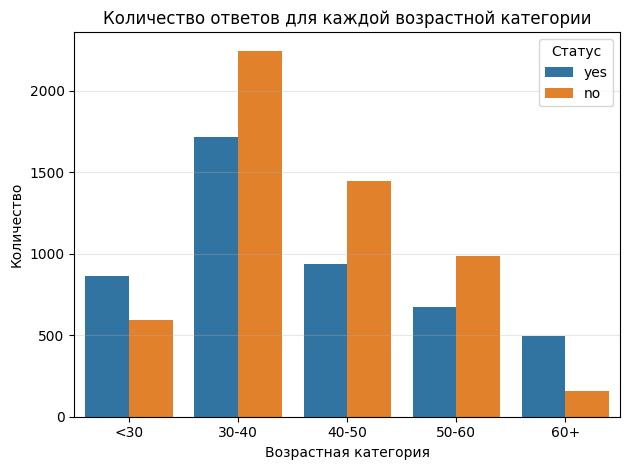

In [ ]:
df['age_cat'] = pd.cut(df['age'],bins=[0,30,40,50,60,9999],labels=['<30', '30-40', '40-50', '50-60', '60+'],right=False)
sns.countplot(x='age_cat', hue='deposit', data=df)
plt.title('Количество ответов для каждой возрастной категории')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество')
plt.legend(title='Статус')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Задания 9 и 10

* постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса (marital)

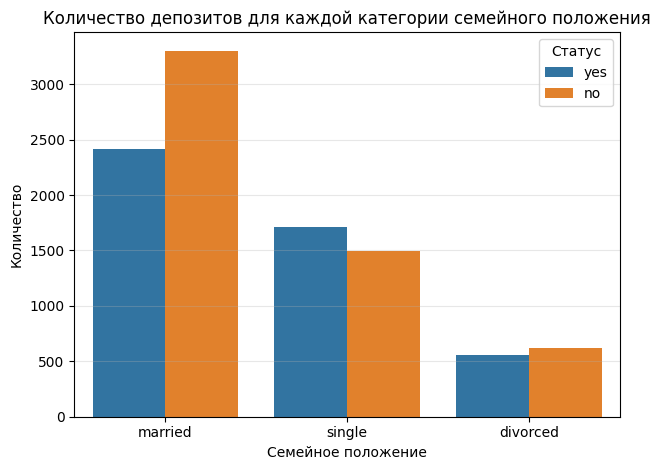

In [ ]:

sns.countplot(x='marital', hue='deposit', data=df)
plt.title('Количество депозитов для каждой категории семейного положения')
plt.xlabel('Семейное положение')
plt.ylabel('Количество')
plt.legend(title='Статус')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* постройте визуализации для открывших и неоткрывших депозит в зависимости от образования

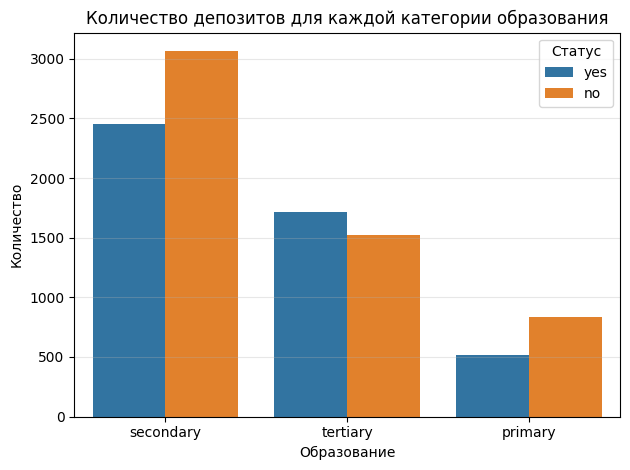

In [ ]:
sns.countplot(x='education', hue='deposit', data=df)
plt.title('Количество депозитов для каждой категории образования')
plt.xlabel('Образование')
plt.ylabel('Количество')
plt.legend(title='Статус')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости

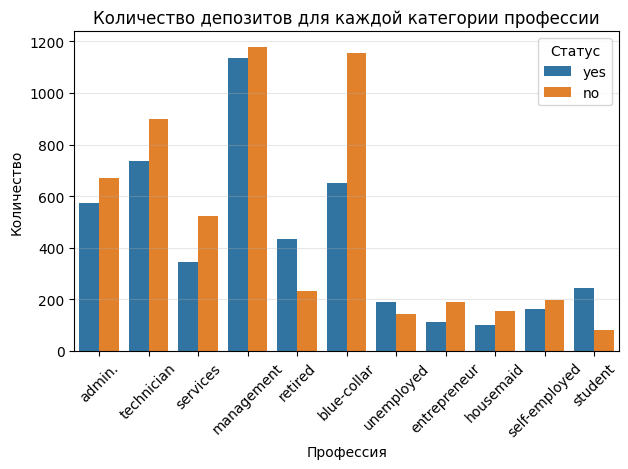

In [ ]:
sns.countplot(x='job', hue='deposit', data=df)
plt.title('Количество депозитов для каждой категории профессии')
plt.xlabel('Профессия')
plt.ylabel('Количество')
plt.legend(title='Статус')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Задание 11

* постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны (если рассматривать тех, кто открыл депозит)

<Axes: xlabel='deposit', ylabel='education-marital'>

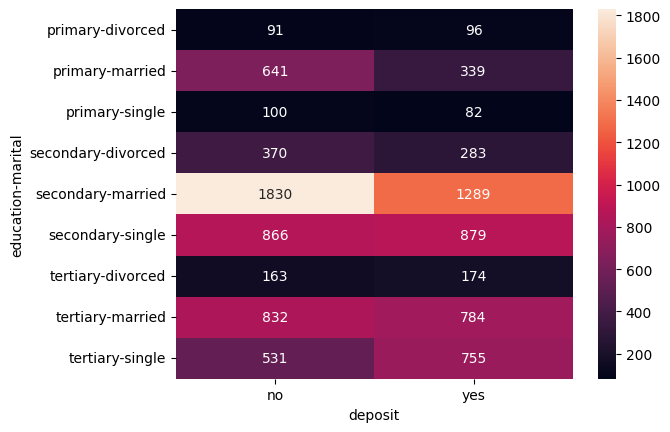

In [ ]:
emd_table = pd.crosstab([df['education'], df['marital']], df['deposit'])

sns.heatmap(emd_table,annot=True,fmt=".4g")

## Часть 3: преобразование данных

### Задание 1

*  преобразуйте уровни образования

In [ ]:
lb = LabelEncoder()
df['education'] = lb.fit_transform(df['education'])
df['education'].sum()

11995

* Удаляем признак возраста, так как есть признак возрастной категории

In [ ]:
df = df.drop(['age'],axis=1)
df['age_cat'] = lb.fit_transform(df['age_cat'])
df['age_cat'].value_counts()

age_cat
0    3961
1    2382
2    1654
4    1455
3     653
Name: count, dtype: int64

### Задания 2 и 3

* преобразуйте бинарные переменные в представление из нулей и единиц

In [ ]:
df['deposit'] = df['deposit'].apply(lambda x: 1 if x == 'yes' else 0)
df['default'] = df['default'].apply(lambda x: 1 if x == 'yes' else 0)
df['housing'] = df['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df['loan'] = df['loan'].apply(lambda x: 1 if x == 'yes' else 0)
df['job'] = df['job'].apply(lambda x: x.replace('.', ''))

### Задание 4

* создайте дамми-переменные

In [ ]:
df = pd.get_dummies(df,['job','marital','contact','month','poutcome'])
df

,education,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,1,0,2343.0,1,0,5,1042,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
1,1,0,45.0,0,0,5,1467,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
2,1,0,1270.0,1,0,5,1389,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
3,1,0,2476.0,1,0,5,579,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
4,2,0,184.0,0,0,5,673,2,-1,0,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,0,0,1.0,1,0,20,257,1,-1,0,...,False,False,False,False,False,False,False,False,False,True
11158,1,0,733.0,0,0,16,83,4,-1,0,...,True,False,False,False,False,False,False,False,False,True
11159,1,0,29.0,0,0,19,156,2,-1,0,...,False,False,False,False,False,False,False,False,False,True
11160,1,0,0.0,0,1,8,9,2,172,5,...,False,False,True,False,False,False,True,False,False,False


### Задания 5 и 6

* постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности

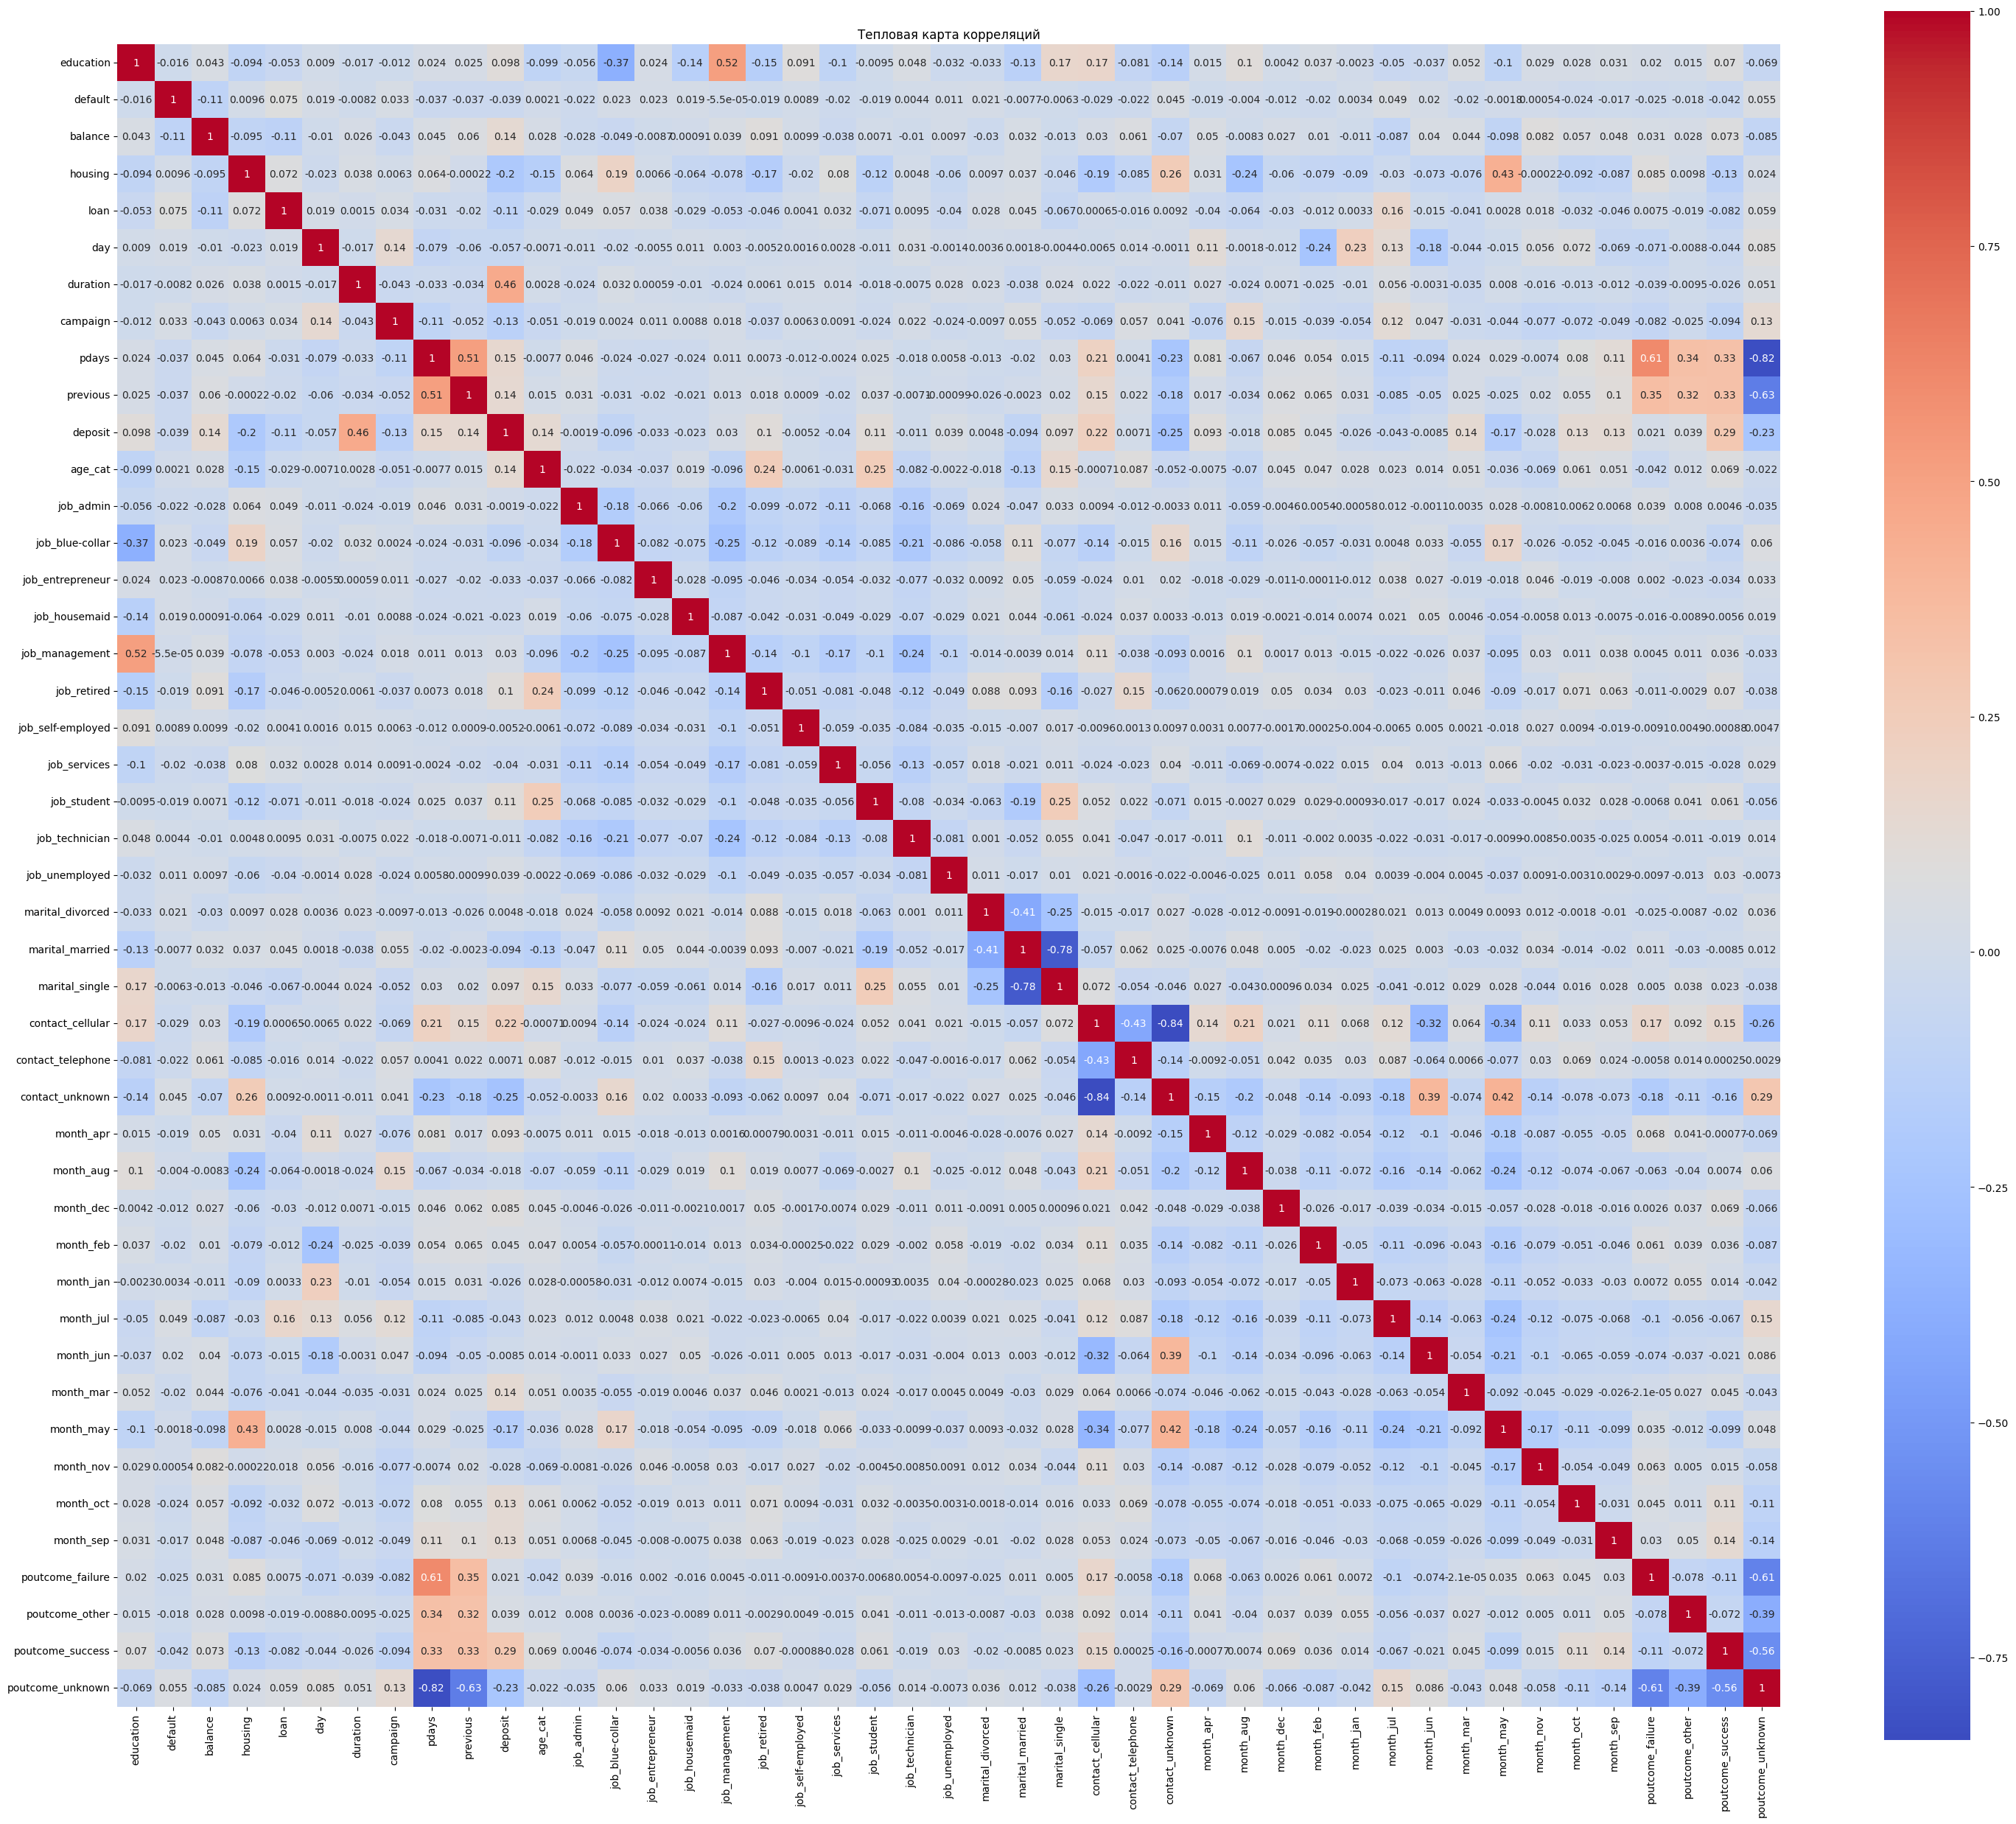

In [ ]:
plt.figure(figsize=(30, 25))
matrix = df.corr()
sns.heatmap(matrix,  
cmap='coolwarm', # Цветовая схема
annot=True,
square=True,
annot_kws={'size': 10}) # Квадратные ячейки
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

### Задания 7 и 8

* рассчитайте необходимые показатели

In [27]:
# деление выборки на тренировочную и тестовую
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [ ]:
print(X_test.info())
print(y_test.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 3335 entries, 3333 to 3818
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   education          3335 non-null   int32  
 1   default            3335 non-null   int64  
 2   balance            3335 non-null   float64
 3   housing            3335 non-null   int64  
 4   loan               3335 non-null   int64  
 5   day                3335 non-null   int64  
 6   duration           3335 non-null   int64  
 7   campaign           3335 non-null   int64  
 8   pdays              3335 non-null   int64  
 9   previous           3335 non-null   int64  
 10  age_cat            3335 non-null   int32  
 11  job_admin          3335 non-null   bool   
 12  job_blue-collar    3335 non-null   bool   
 13  job_entrepreneur   3335 non-null   bool   
 14  job_housemaid      3335 non-null   bool   
 15  job_management     3335 non-null   bool   
 16  job_retired        3335 no

### Задание 9

* с помощью SelectKBest отберите 15 наиболее подходящих признаков

In [ ]:
select = SelectKBest(score_func=f_classif, k=15)
X_new = select.fit_transform(X_train, y_train)
select.get_feature_names_out()


array(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_cat', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

* оставляем только самые важные признаки для дальнейшей работы

In [ ]:
X_train_new = X_train[['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown']]
X_test_new = X_test[['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown']]

### Задание 10

* нормализуйте данные с помощью minmaxsxaler

In [ ]:
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train_new)
X_train_scaled = scaler.transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)
np.mean(X_test_scaled[:, 0])

0.46823674223097866

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

* обучите логистическую регрессию и рассчитайте метрики качества

In [ ]:
log_reg = linear_model.LogisticRegression(solver='sag',random_state=42,max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_test_pred = log_reg.predict(X_test_scaled)

print(metrics.classification_report(y_test_pred, y_test))


              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1963
           1       0.73      0.83      0.78      1372

    accuracy                           0.80      3335
   macro avg       0.80      0.81      0.80      3335
weighted avg       0.81      0.80      0.81      3335



### Задания 2,3,4

* обучите решающие деревья, настройте максимальную глубину

In [ ]:
scores_train = {}
scores_test = {}
params = np.arange(2,11,1)

for param in params:
    dtc = tree.DecisionTreeClassifier(criterion = 'entropy', random_state = 42, max_depth=param)
    dtc.fit(X_train_scaled, y_train)
    y_test_pred = dtc.predict(X_test_scaled)
    y_train_pred = dtc.predict(X_train_scaled)
    scores_test[param] = metrics.accuracy_score(y_test_pred, y_test)
    scores_train[param] = metrics.accuracy_score(y_train_pred, y_train)
    
print(scores_train)
print(scores_test)
print(f'Наилучшая метрика accuracy при максимальной глубине: {max(scores_test, key=scores_test.get)}')


{2: 0.7288035450516986, 3: 0.7757754800590841, 4: 0.7757754800590841, 5: 0.8038404726735598, 6: 0.8163958641063516, 7: 0.8231905465288035, 8: 0.8316100443131462, 9: 0.839586410635155, 10: 0.8542097488921714}
{2: 0.7178410794602699, 3: 0.7703148425787106, 4: 0.7703148425787106, 5: 0.7943028485757121, 6: 0.8041979010494753, 7: 0.8044977511244378, 8: 0.8041979010494753, 9: 0.7976011994002998, 10: 0.8014992503748126}
Наилучшая метрика accuracy при максимальной глубине: 7


### Задание 5

* подберите оптимальные параметры с помощью gridsearch

In [ ]:
params = {'min_samples_split': [2, 5, 7, 10],
          'max_depth':[3,5,7]}

grid_search_forest = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42,criterion = 'entropy'), 
    param_grid=params,
    n_jobs = -1,
    cv=3,
    scoring=('f1'), 
    return_train_score=True
)  
#замер времени
%time grid_search_forest.fit(X_train_scaled, y_train) 
#предсказание результата
y_test_pred = grid_search_forest.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search_forest.best_params_))

CPU times: total: 266 ms
Wall time: 2.62 s
f1_score на тестовом наборе: 0.78
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 2}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

* обучите на ваших данных случайный лес

In [ ]:
rfc = ensemble.RandomForestClassifier(n_estimators = 100, criterion = 'gini', min_samples_leaf = 5, max_depth = 10, random_state = 42)
rfc.fit(X_train_scaled, y_train)
y_test_pred = rfc.predict(X_test_scaled)
print(metrics.classification_report(y_test_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1738
           1       0.83      0.80      0.82      1597

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3

* используйте для классификации градиентный бустинг и сравните качество со случайным лесом

In [ ]:
# Создаем модель градиентного бустинга
gb = ensemble.GradientBoostingClassifier(
    learning_rate = 0.05,
    n_estimators = 300,
    min_samples_leaf = 5,
    max_depth = 5,
    random_state = 42)
# Обучаем модель
gb.fit(X_train_scaled, y_train)
# Формируем предсказание для тестовой выборки
y_test_pred = gb.predict(X_test_scaled)
# Посмотрим на основные метрики классификации
print(f'f1_score на тестовой выборке: {round(metrics.f1_score(y_test, y_test_pred),2)}')

f1_score на тестовой выборке: 0.81


### Задание 4

* объедините уже известные вам алгоритмы с помощью стекинга 

In [ ]:
# Создаем список кортежей вида: (наименование модели, модель)

estimators = [
    ('lr', linear_model.LogisticRegression(solver='sag',random_state=42,max_iter=1000)),
    ('dt', tree.DecisionTreeClassifier(criterion = 'entropy', random_state = 42, max_depth = 7, min_samples_split = 10)),
    ('rfc', ensemble.RandomForestClassifier(n_estimators = 100, criterion = 'gini', min_samples_leaf = 5, max_depth = 10, random_state = 42)),
    ( 'gb', ensemble.GradientBoostingClassifier(learning_rate = 0.05, n_estimators = 300, min_samples_leaf = 5, max_depth = 5, random_state = 42))
]

# Создаем объект класса стекинг
reg = ensemble.StackingClassifier(
    estimators=estimators,
    final_estimator= linear_model.LogisticRegression(random_state=42)
)
# Обучаем модель
reg.fit(X_train_scaled, y_train)
y_test_pred = reg.predict(X_test_scaled)
print(f'Precision метрика на тестовой выборке: {round(metrics.precision_score(y_test, y_test_pred),2)}')

Precision метрика на тестовой выборке: 0.81


### Задание 5

* оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

In [ ]:
feature_importance = pd.Series(
    gb.feature_importances_,
    index=X_train_new.columns
).sort_values(ascending=False)

feature_importance.head(10)

duration            0.514145
poutcome_success    0.118988
contact_unknown     0.078994
balance             0.061918
pdays               0.055452
housing             0.050464
month_mar           0.027025
month_oct           0.019516
campaign            0.018008
month_sep           0.015613
dtype: float64

### Задания 6,7,8

* реализуйте оптимизацию гиперпараметров с помощью Optuna

In [ ]:
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  # создаем модель
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  
  score = metrics.f1_score(y_test, model.predict(X_test_scaled))
  
  return score

In [40]:
%%time
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)

[I 2026-02-03 22:18:05,421] A new study created in memory with name: RandomForestClassifier
[I 2026-02-03 22:18:05,897] Trial 0 finished with value: 0.8149084017687934 and parameters: {'n_estimators': 119, 'max_depth': 29, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8149084017687934.
[I 2026-02-03 22:18:06,343] Trial 1 finished with value: 0.8173198482932996 and parameters: {'n_estimators': 129, 'max_depth': 14, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.8173198482932996.
[I 2026-02-03 22:18:06,976] Trial 2 finished with value: 0.819672131147541 and parameters: {'n_estimators': 180, 'max_depth': 12, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.819672131147541.
[I 2026-02-03 22:18:07,593] Trial 3 finished with value: 0.8151419558359622 and parameters: {'n_estimators': 172, 'max_depth': 24, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.819672131147541.
[I 2026-02-03 22:18:07,931] Trial 4 finished with value: 0.817435249526216 and parameters: {'n_esti

CPU times: total: 10.5 s
Wall time: 10.5 s


In [41]:
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

Наилучшие значения гиперпараметров {'n_estimators': 152, 'max_depth': 10, 'min_samples_leaf': 2}
f1_score на обучающем наборе: 0.82


In [42]:
# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(**study.best_params,random_state=42)

model.fit(X_train_scaled, y_train)

y_test_pred = model.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test_pred, y_test)))

y_test_pred2 = model.predict(X_test_scaled)
print("accuracy на тестовом наборе: {:.2f}".format(metrics.accuracy_score(y_test_pred2, y_test)))

f1_score на тестовом наборе: 0.82
accuracy на тестовом наборе: 0.83


* ## В заключении можем сказать, что лучшим алгоритмом оказался RandomForestClassifier с f1_score метрикой в 0.82. Да, с помощью алгоритма оптимизации гиперпараметров Optuna мы достигли такого же результата, но потрптили больше времени и ресурсов вычислительной машины. Так что, стандартная модель будет нашим выбором в решении этой задачи.